In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

sys.path.append(str(root_path))
params_path = root_path / "params/"

import json
import logging

import matplotlib.pyplot as plt
import numpy as np

from domain.distributions import GaussianTail, QGaussianTail
from plotting.plot_style import plot_style
from src.mle_multiple_inits import mle_fit_multiple_inits
from utils.sampling.sampling_tails import sample_gaussian_tail, sample_qgaussian_tail
from utils.seed import set_seed

In [2]:
# Force verbose logging in notebook

logging.basicConfig(level=logging.INFO, force=True)

In [3]:
with open(params_path / "mle_constraints.json", "r") as f:
    constraints = json.load(f)

constraints_gaussian_tail = {
    k: tuple(v) for k, v in constraints["constraints_gaussian_tail"].items()
}

constraints_qgaussian_tail = {
    k: tuple(v) for k, v in constraints["constraints_qgaussian_tail"].items()
}

In [4]:
set_seed(123)

# Gaussian tail

## Generate synthetic data with rejection sampling

In [5]:
# Gaussian
true_sigma = 1.0
n = 5000

true_dist = GaussianTail(sigma=true_sigma)
data_gaussian = sample_gaussian_tail(dist=true_dist, n=n)

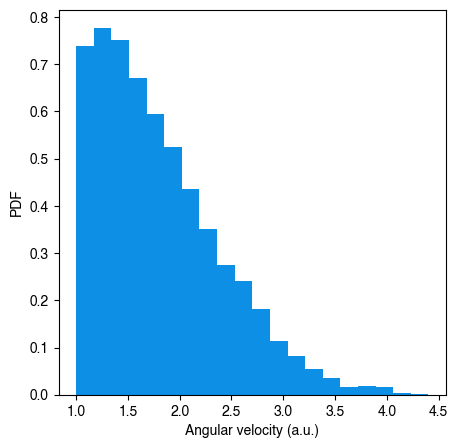

In [6]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(data_gaussian, bins=20, density=True)

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    plt.show()

## MLE fit

In [7]:
sigma_inits = [
    {"sigma": 0.1}
]  # to run with multiple inits pass [{"sigma": <val>}, {"sigma": <val>}, {"sigma": <val>}, ...]

result = mle_fit_multiple_inits(
    data=data_gaussian,
    distribution="gaussian_tail",
    init_list=sigma_inits,
    constraints=constraints_gaussian_tail,
    max_iter=500,
    std_threshold=1,
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'sigma': 0.1}
INFO:root:Starting MLE optimization for gaussian_tail distribution
INFO:root:Initial parameters: {'sigma': 0.1}
INFO:root:neg_log_likelihood=69023.459131, delta_x=5.00e-03, delta_f=1.88e+03, params=[0.105]
INFO:root:neg_log_likelihood=67168.870157, delta_x=5.00e-03, delta_f=1.85e+03, params=[0.11]
INFO:root:neg_log_likelihood=65316.152725, delta_x=5.00e-03, delta_f=1.85e+03, params=[0.115]
INFO:root:neg_log_likelihood=61707.987790, delta_x=1.00e-02, delta_f=3.61e+03, params=[0.125]
INFO:root:neg_log_likelihood=58249.181405, delta_x=1.00e-02, delta_f=3.46e+03, params=[0.135]
INFO:root:neg_log_likelihood=51802.637694, delta_x=2.00e-02, delta_f=6.45e+03, params=[0.155]
INFO:root:neg_log_likelihood=45972.847069, delta_x=2.00e-02, delta_f=5.83e+03, params=[0.175]
INFO:root:neg_log_likelihood=36033.945562, delta_x=4.00e-02, delta_f=9.94e+03, params=[0.215]
INFO:root:neg_log_likelihood=28124.323146, delta_x=4.00e-02, delta_f=7.91e+03, para

Optimization terminated successfully.
         Current function value: 3625.001261
         Iterations: 33
         Function evaluations: 66


In [8]:
sigma_fit = result[0]["sigma"][0]
fitted_distribution = GaussianTail(sigma=sigma_fit)

In [9]:
x_range = np.linspace(data_gaussian.min(), data_gaussian.max(), 100)
pdf = fitted_distribution.pdf(x=x_range)

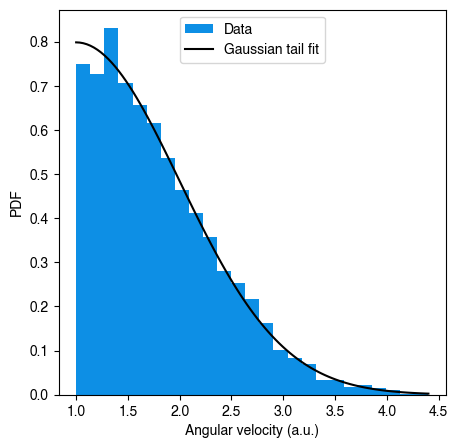

In [10]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(data_gaussian, bins=25, density=True, label="Data")
    ax.plot(x_range, pdf, color="black", lw=1.5, label="Gaussian tail fit")

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="upper center")

    plt.show()

# q-Gaussian tail

## Generate synthetic data with rejection sampling

In [11]:
# Gaussian
true_q_super = 1.3
true_q_sub = 0.8
true_q_gauss = 1.0

true_beta = 20
true_beta_gauss = 0.5  # chosen so that Gaussian std = 1

n = 5000

true_dist_super = QGaussianTail(q=true_q_super, beta=true_beta)
true_dist_sub = QGaussianTail(q=true_q_sub, beta=true_beta)
true_dist_gauss = QGaussianTail(q=true_q_gauss, beta=true_beta_gauss)

data_qgaussian_super = sample_gaussian_tail(dist=true_dist_super, n=n)
data_qgaussian_sub = sample_qgaussian_tail(dist=true_dist_sub, n=n)
data_qgaussian_gauss = sample_gaussian_tail(dist=true_dist_gauss, n=n)

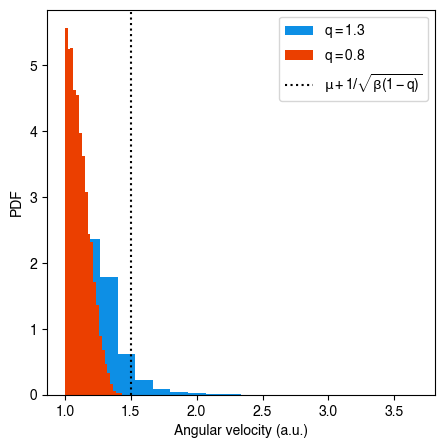

In [12]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(
        data_qgaussian_super,
        bins=20,
        color=colors[0],
        density=True,
        label=r"$q = $" + f"{true_q_super}",
    )
    ax.hist(
        data_qgaussian_sub,
        bins=20,
        color=colors[1],
        density=True,
        label=r"$q = $" + f"{true_q_sub}",
    )

    # Theoretical bound q-Gaussian compact support: mu + 1 / sqrt(beta * (1-q))
    ax.axvline(
        1.0 + 1 / np.sqrt(true_beta * (1 - true_q_sub)),
        color="black",
        ls="dotted",
        label=r"$\mu + 1 / \sqrt{\beta (1 - q)}$",
    )

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="upper right")

    plt.show()

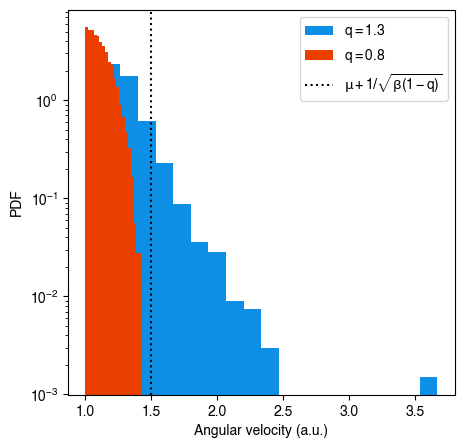

In [13]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(
        data_qgaussian_super,
        bins=20,
        color=colors[0],
        density=True,
        label=r"$q = $" + f"{true_q_super}",
    )
    ax.hist(
        data_qgaussian_sub,
        bins=20,
        color=colors[1],
        density=True,
        label=r"$q = $" + f"{true_q_sub}",
    )

    # Theoretical bound q-Gaussian compact support: m + 1 / sqrt(beta * (1-q))
    ax.axvline(
        1.0 + 1 / np.sqrt(true_beta * (1 - true_q_sub)),
        color="black",
        ls="dotted",
        label=r"$\mu + 1 / \sqrt{\beta (1 - q)}$",
    )

    ax.set_yscale("log")
    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="upper right")

    plt.show()

## MLE fit

In [14]:
qgaussian_inits = [
    {"q": 1.3, "beta": 5}
]  # to run with multiple inits pass [{"q": <val>, "beta": <val>}, {"q": <val>, "beta": <val>}, ...]

result_super = mle_fit_multiple_inits(
    data=data_qgaussian_super,
    distribution="qgaussian_tail",
    init_list=qgaussian_inits,
    constraints=constraints_qgaussian_tail,
    max_iter=500,
    std_threshold=1,
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'q': 1.3, 'beta': 5}
INFO:root:Starting MLE optimization for qgaussian_tail distribution
INFO:root:Initial parameters: {'q': 1.3, 'beta': 5}
INFO:root:neg_log_likelihood=-2071.607220, delta_x=6.50e-02, delta_f=1.08e+02, params=[1.365 5.   ]
INFO:root:neg_log_likelihood=-2221.949552, delta_x=2.50e-01, delta_f=1.50e+02, params=[1.3  5.25]
INFO:root:neg_log_likelihood=-2312.360475, delta_x=6.50e-02, delta_f=9.04e+01, params=[1.235 5.25 ]
INFO:root:neg_log_likelihood=-2402.766659, delta_x=1.25e-01, delta_f=9.04e+01, params=[1.17  5.375]
INFO:root:neg_log_likelihood=-2429.433721, delta_x=2.50e-01, delta_f=2.67e+01, params=[1.17  5.625]
INFO:root:neg_log_likelihood=-2497.294172, delta_x=3.12e-01, delta_f=6.79e+01, params=[1.105  5.9375]
INFO:root:neg_log_likelihood=-2480.046243, delta_x=1.30e-01, delta_f=1.72e+01, params=[0.975  6.0625]
INFO:root:neg_log_likelihood=-2256.316688, delta_x=5.62e-01, delta_f=2.24e+02, params=[0.91  6.625]
INFO:root:neg_log

Optimization terminated successfully.
         Current function value: -2521.617708
         Iterations: 73
         Function evaluations: 143


In [15]:
qgaussian_inits = [
    {"q": 1.5, "beta": 20}
]  # to run with multiple inits pass [{"q": <val>, "beta": <val>}, {"q": <val>, "beta": <val>}, ...]

result_sub = mle_fit_multiple_inits(
    data=data_qgaussian_sub,
    distribution="qgaussian_tail",
    init_list=qgaussian_inits,
    constraints=constraints_qgaussian_tail,
    max_iter=500,
    std_threshold=1,
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'q': 1.5, 'beta': 20}
INFO:root:Starting MLE optimization for qgaussian_tail distribution
INFO:root:Initial parameters: {'q': 1.5, 'beta': 20}
INFO:root:neg_log_likelihood=-5203.261905, delta_x=7.50e-02, delta_f=1.76e+02, params=[ 1.575 20.   ]
INFO:root:neg_log_likelihood=-5434.482294, delta_x=1.00e+00, delta_f=2.31e+02, params=[ 1.5 21. ]
INFO:root:neg_log_likelihood=-5591.804397, delta_x=7.50e-02, delta_f=1.57e+02, params=[ 1.425 21.   ]
INFO:root:neg_log_likelihood=-5756.613202, delta_x=5.00e-01, delta_f=1.65e+02, params=[ 1.35 21.5 ]
INFO:root:neg_log_likelihood=-5798.634208, delta_x=1.00e+00, delta_f=4.20e+01, params=[ 1.35 22.5 ]
INFO:root:neg_log_likelihood=-5962.022625, delta_x=1.25e+00, delta_f=1.63e+02, params=[ 1.275 23.75 ]
INFO:root:neg_log_likelihood=-6155.526793, delta_x=5.00e-01, delta_f=1.94e+02, params=[ 1.125 24.25 ]
INFO:root:neg_log_likelihood=-6255.533047, delta_x=1.62e+00, delta_f=1.00e+02, params=[ 0.9375 25.875 ]
INFO:ro

Optimization terminated successfully.
         Current function value: -6274.726297
         Iterations: 78
         Function evaluations: 162


In [16]:
q_fit_super = result_super[0]["q"][0]
beta_fit_super = result_super[0]["beta"][0]

fitted_distribution = QGaussianTail(q=q_fit_super, beta=beta_fit_super)

q_fit_sub = result_sub[0]["q"][0]
beta_fit_sub = result_sub[0]["beta"][0]

fitted_distribution_sub = QGaussianTail(q=q_fit_sub, beta=beta_fit_sub)

In [17]:
x_range_super = np.linspace(data_qgaussian_super.min(), data_qgaussian_super.max(), 100)
pdf_super = fitted_distribution.pdf(x=x_range_super)

x_range_sub = np.linspace(data_qgaussian_sub.min(), data_qgaussian_sub.max(), 100)
pdf_sub = fitted_distribution_sub.pdf(x=x_range_sub)

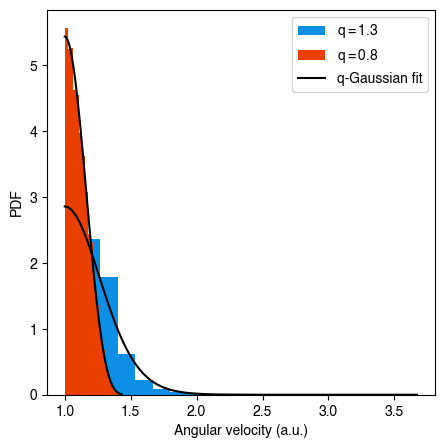

In [18]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(
        data_qgaussian_super,
        bins=20,
        color=colors[0],
        density=True,
        label=r"$q = $" + f"{true_q_super}",
    )
    ax.hist(
        data_qgaussian_sub,
        bins=20,
        color=colors[1],
        density=True,
        label=r"$q = $" + f"{true_q_sub}",
    )

    ax.plot(x_range_super, pdf_super, color="black", lw=1.5, label="q-Gaussian fit")
    ax.plot(x_range_sub, pdf_sub, color="black", lw=1.5)

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="upper right")

    plt.show()

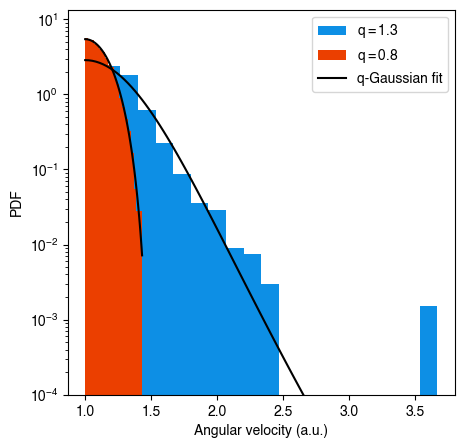

In [19]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(
        data_qgaussian_super,
        bins=20,
        color=colors[0],
        density=True,
        label=r"$q = $" + f"{true_q_super}",
    )
    ax.hist(
        data_qgaussian_sub,
        bins=20,
        color=colors[1],
        density=True,
        label=r"$q = $" + f"{true_q_sub}",
    )

    ax.plot(x_range_super, pdf_super, color="black", lw=1.5, label="q-Gaussian fit")
    ax.plot(x_range_sub, pdf_sub, color="black", lw=1.5)

    ax.set_yscale("log")
    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")
    ax.set_ylim(1e-4)

    ax.legend(loc="upper right")

    plt.show()

## Fall back to Gaussian of q-Gaussian

In [20]:
qgaussian_inits = [
    {"q": 1.3, "beta": 5}
]  # to run with multiple inits pass [{"q": <val>, "beta": <val>}, {"q": <val>, "beta": <val>}, ...]

result_gauss = mle_fit_multiple_inits(
    data=data_qgaussian_gauss,
    distribution="qgaussian_tail",
    init_list=qgaussian_inits,
    constraints=constraints_qgaussian_tail,
    max_iter=500,
    std_threshold=1,
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'q': 1.3, 'beta': 5}
INFO:root:Starting MLE optimization for qgaussian_tail distribution
INFO:root:Initial parameters: {'q': 1.3, 'beta': 5}
INFO:root:neg_log_likelihood=6651.908720, delta_x=6.50e-02, delta_f=7.36e+02, params=[1.365 5.   ]
INFO:root:neg_log_likelihood=7600.462526, delta_x=2.50e-01, delta_f=9.49e+02, params=[1.3  5.25]
INFO:root:neg_log_likelihood=6474.452985, delta_x=5.00e-01, delta_f=1.13e+03, params=[1.365 4.75 ]
INFO:root:neg_log_likelihood=6026.918585, delta_x=2.50e-01, delta_f=4.48e+02, params=[1.3975 4.5   ]
INFO:root:neg_log_likelihood=5588.431571, delta_x=6.50e-02, delta_f=4.38e+02, params=[1.4625 4.5   ]
INFO:root:neg_log_likelihood=5070.873803, delta_x=2.50e-01, delta_f=5.18e+02, params=[1.54375 4.25   ]
INFO:root:neg_log_likelihood=4748.960012, delta_x=5.00e-01, delta_f=3.22e+02, params=[1.57625 3.75   ]
INFO:root:neg_log_likelihood=4346.110817, delta_x=6.25e-01, delta_f=4.03e+02, params=[1.681875 3.125   ]
INFO:root:n

Optimization terminated successfully.
         Current function value: 3602.805139
         Iterations: 77
         Function evaluations: 149


In [21]:
q_fit_gauss = result_gauss[0]["q"][0]
beta_fit_gauss = result_gauss[0]["beta"][0]

fitted_distribution = QGaussianTail(q=q_fit_gauss, beta=beta_fit_gauss)

In [22]:
x_range_gauss = np.linspace(data_qgaussian_gauss.min(), data_qgaussian_gauss.max(), 100)
pdf_gauss = fitted_distribution.pdf(x=x_range_gauss)

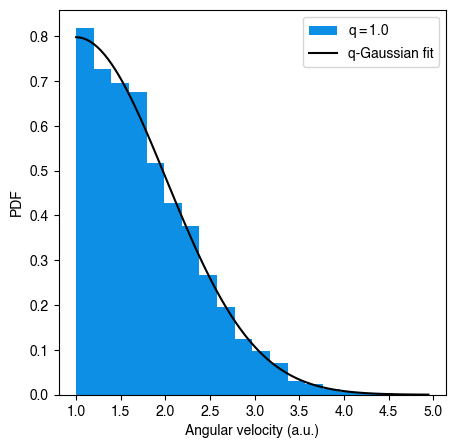

In [23]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # Data sampled from Gaussian fallback in q-Gaussian tail
    ax.hist(
        data_qgaussian_gauss,
        bins=20,
        color=colors[0],
        density=True,
        label=r"$q = $" + f"{true_q_gauss}",
    )

    ax.plot(x_range_gauss, pdf_gauss, color="black", lw=1.5, label="q-Gaussian fit")

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="upper right")

    plt.show()